In [1]:
import numpy as np
import matplotlib.pyplot as plt

batch_size = 2000
file = 'HighSNR.iq'


recording = np.fromfile(file, dtype=np.complex64)
# plt.figure(figsize=(6, 3), dpi=200)
# plt.plot(np.abs(recording))
# plt.title('Recording')
# plt.xlabel('Sample')
# plt.ylabel('Amplitude')
# plt.show()

#divide the recording into the batches of batch_size but the las batch can be anysize
if recording.size % batch_size != 0:
    recording = np.concatenate((recording, np.zeros(batch_size - recording.size % batch_size)))
recording_batches = recording.reshape(-1, batch_size)

print(recording.shape, recording_batches.shape)

# now I want to process the recording in batches








(20000000,) (10000, 2000)


In [2]:
res = []

# Suppose we have a threshold factor to go above the noise floor.
THRESHOLD = 500.0   # e.g. 5 times the average noise amplitude


Noise = 0.0
for i in range(1000):
    batch = recording_batches[i].copy()
    Noise += np.std(np.abs(batch)**2)

Noise /= 1000
threshold = THRESHOLD * Noise



State = 0

for i in range(1000,recording_batches.shape[0]):
    # process the batch
    batch = recording_batches[i].copy()
    bathc_power = np.max(np.abs(batch)**2)

    if State == 0: # Wait for the rising edge of the begining burst
        # check if we received a burst
        if  bathc_power> threshold:
            State = 1
            res.extend(batch)
        else:
            # we are still in the noise state, so we can insert some zeros
            res.extend([0]*100)
    elif State == 1: # Wait for the falling edge of the begining burst
        # we are detecting the falling edge
        if bathc_power < threshold:
            State = 2
        res.extend(batch)
    elif State == 2: # Wait for the rising edge of the ending burst
        if bathc_power > threshold:
            State = 3
        res.extend(batch)
    elif State == 3: # Wait for the falling edge of the ending burst
        if bathc_power < threshold:
            # we have a signal, but it is below the threshold, so we stop recording
            State = 0
        res.extend(batch)
  
        

    

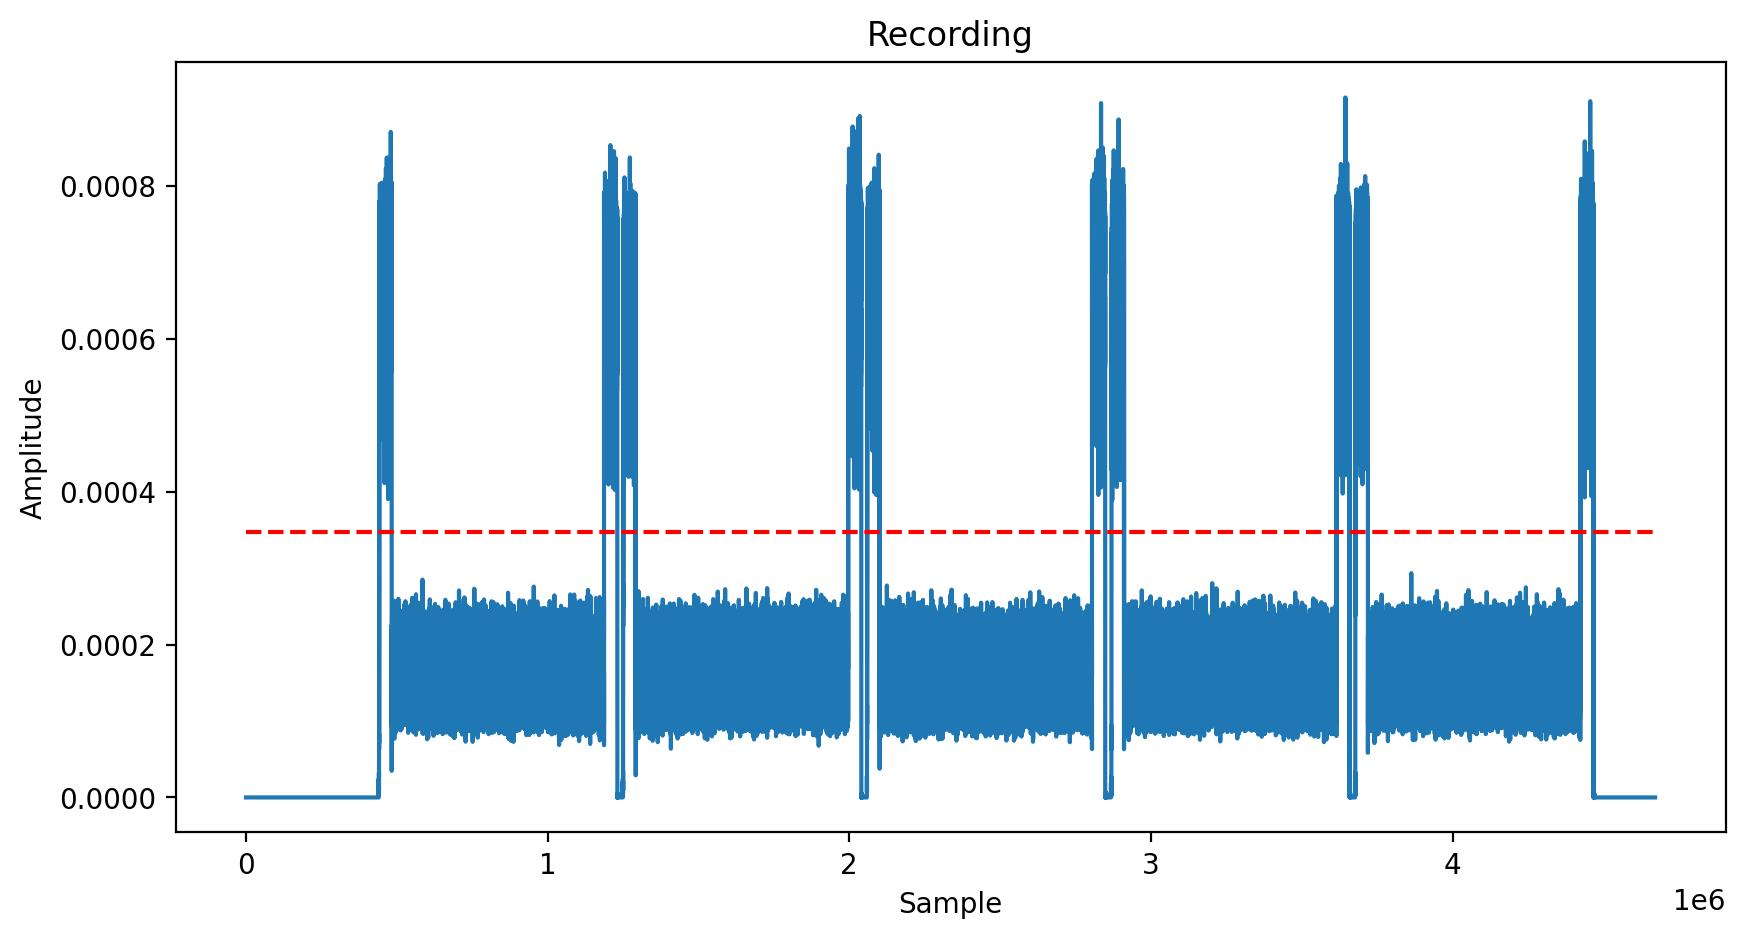

In [3]:

# At the end the res should contain the signal and replace the noise with 0. And also it should work for any batch size
plt.figure(figsize=(10, 5), dpi=200)
plt.plot(np.abs(res)**2)
plt.title('Recording')
plt.hlines(threshold, 0, len(res), colors='r', linestyles='dashed')
plt.xlabel('Sample')
plt.ylabel('Amplitude')
plt.show()